In [1]:
import xarray as xr
import shapely
import dask.array as da
import numpy as np
import geopandas as gpd
from pyproj import CRS, Transformer
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# CRSs
WGS84 = CRS('epsg:4326')  # WGS84 : (lon, lat)
ETRS89UTM = CRS('epsg:25834') # ETRS89 / UTM zone 34N : (x, y)

infol = '/scratch/project_2018610/connectivity/rasters/15_part_per_km2/'
outfol = '/projappl/project_2018610/scripts_jupyter_notebook/Density_map/Plot_density_map/'
shpfile = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
shpfile_coast = '/projappl/project_2018610/data/coastal/nemo_nordic_10-20m_polygons.shp'
poly = gpd.read_file(shpfile)
poly_coast = gpd.read_file(shpfile_coast)

In [2]:
# transform the coordinates of the farms

poly = poly.to_crs(ETRS89UTM)

#### Generate one density map averaging over years ####

In [3]:
# create a dictionnary with the number of particles per seeding for each farm
# nb_part = area * density (15 part/km² or 6 part/km² for the farms 11 and 13)
nb_part = {}
sum_part = 0
for _, row in poly.iterrows():
    ID = row["FarmID"]
    if ID!=11 and ID!=13 :
        nb_part[ID]=int(row["Area_km2"])*15
    else :
        nb_part[ID]=int(row["Area_km2"])*6
    sum_part+=nb_part[ID]

In [4]:
# Build a colormap where 0 = white, rest = YlOrRd
base_cmap = plt.cm.YlOrRd
colors = base_cmap(np.linspace(0, 1, 256))
colors[0] = [1, 1, 1, 1]  # RGBA white for the lowest bin
custom_cmap = mcolors.LinearSegmentedColormap.from_list("YlOrRd_white0", colors)
custom_cmap.set_under('white')  # anything below vmin also white

In [16]:
# Build one density map averaging over the four years

small = [2, 3, 4, 5, 9, 14, 15, 16, 17, 18, 19] # Smaller farms: one simulation for the whole summer
medium = [1, 6, 7, 8, 10, 12] # Medium farms : summer divided in two simulations

years = [2012, 2013, 2017, 2018]

da = xr.DataArray(np.zeros((200, 144)), dims=("y", "x"))
for year in years:    
    
    for polygon in range(2, 20):
        if polygon in small :           
            raster_nc = 'simulation_farm_{}_June_September_{}_uniqsum_raster_metres.nc'.format(polygon, year)
            d = xr.open_dataset(infol+raster_nc)        
            da += nb_part[polygon]*d["N_count"]
            
        elif polygon in medium :            
            raster_nc1 = 'simulation_farm_{}_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 6)
            raster_nc2 = 'simulation_farm_{}_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 7)
            d1 = xr.open_dataset(infol+raster_nc1)
            d2 = xr.open_dataset(infol+raster_nc2)
            # average the data
            da += nb_part[polygon]*(d1["N_count"]+d2["N_count"])/2
            
        else :  # Large farms : summer divided in 2 + lower density of particles
            raster_nc1 = 'simulation_farm_{}_6_part_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 6)
            raster_nc2 = 'simulation_farm_{}_6_part_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 7)
            d1 = xr.open_dataset(infol+raster_nc1)
            d2 = xr.open_dataset(infol+raster_nc2)
            # average the data
            da += nb_part[polygon]*(d1["N_count"]+d2["N_count"])/2
            
da = da*100/(sum_part*4) 

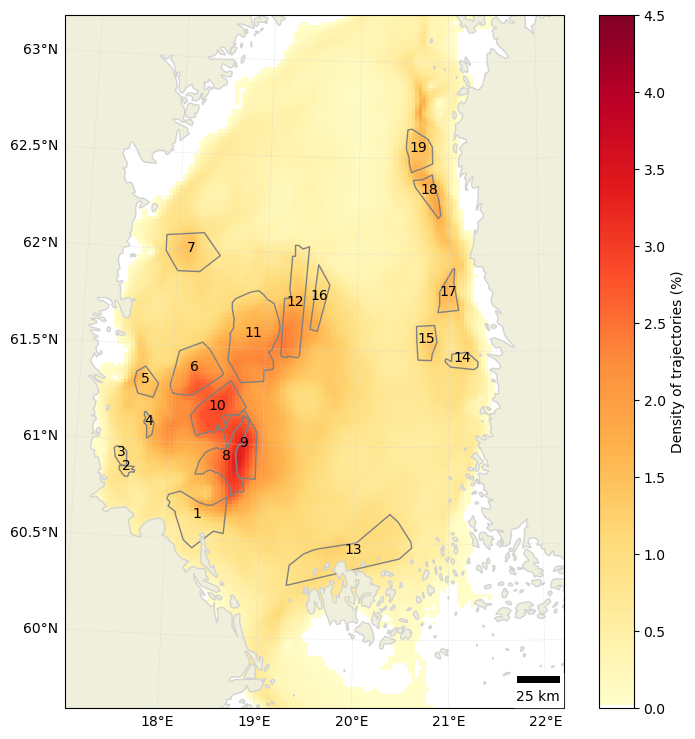

In [18]:
# plot the density map
utm_proj = ccrs.UTM(zone=34)

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={"projection": utm_proj}
)

norm = mpl.colors.Normalize(vmin=0, vmax=4.5)

mesh = ax.pcolormesh(
    da.x.values,
    da.y.values,
    da.values,
    cmap=custom_cmap,
    norm=norm,
    transform=utm_proj,
    shading='auto'
)

plt.colorbar(mesh, ax=ax, label='Density of trajectories (%)')

# Plot the wind farm as polygons
poly.plot(edgecolor="grey", facecolor="none",ax=ax)
for _, row in poly.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, str(row["FarmID"]), color='black', fontsize=10, ha='center')

# --- Lat/Lon gridlines  ---
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),   # gridlines defined in lat/lon
    draw_labels=True,
    linewidth=0.5,
    color='lightgray',
    alpha=0.5,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False
gl.xformat = "DMS"  # or leave default decimal degrees
gl.yformat = "DMS"

# Add land feature, overriding the default negative zorder so it shows
# above the background image.
ax.add_feature(cfeature.LAND, zorder=1, edgecolor='lightgrey')

scalebar = ScaleBar(1, location='lower right', units='m', length_fraction=0.1, rotation='horizontal-only')
ax.add_artist(scalebar)
# ax.set_title(f"Histogram averaged over years")
plt.savefig("Plot_density_map/selected_figures/density_map_mean.png")
    
plt.show()

#### Generate individual density maps ####

In [9]:
# Plot individual maps with the coastline (for each year and each farm)

small = [2, 3, 4, 5, 9, 14, 15, 16, 17, 18, 19] # Smaller farms: one simulation for the whole summer
medium = [1, 6, 7, 8, 10, 12] # Medium farms : summer divided in two simulations

years = [2012]

for year in years:
    outfol = f'/projappl/project_2018610/scripts_jupyter_notebook/Density_map/Plot_density_map/{year}/'
    for polygon in range(1, 20):
        if polygon in small :           
            raster_nc = 'simulation_farm_{}_June_September_{}_uniqsum_raster_metres.nc'.format(polygon, year)
            d = xr.open_dataset(infol+raster_nc)        
            da = d["N_count"]
            
        elif polygon in medium :            
            raster_nc1 = 'simulation_farm_{}_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 6)
            raster_nc2 = 'simulation_farm_{}_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 7)
            d1 = xr.open_dataset(infol+raster_nc1)
            d2 = xr.open_dataset(infol+raster_nc2)
            # average the data
            da = (d1["N_count"]+d2["N_count"])/2
            
        else :  # Large farms : summer divided in 2 + lower density of particles
            raster_nc1 = 'simulation_farm_{}_6_part_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 6)
            raster_nc2 = 'simulation_farm_{}_6_part_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 7)
            d1 = xr.open_dataset(infol+raster_nc1)
            d2 = xr.open_dataset(infol+raster_nc2)
            # average the data
            da = (d1["N_count"]+d2["N_count"])/2
        
        utm_proj = ccrs.UTM(zone=34)
        
        fig, ax = plt.subplots(
            figsize=(8, 6),
            subplot_kw={"projection": utm_proj}
        )
        
        # plot as 2D colored map
        da.plot(
            ax=ax,
            cmap="Greys",   # light -> dark grey
            robust=False    # optional, improves contrast
        )
        #Plot the wind farm as polygons
        poly.plot(edgecolor="black", facecolor="none",ax=ax)
        for _, row in poly.iterrows():
            x, y = row.geometry.centroid.x, row.geometry.centroid.y
            ax.text(x, y, str(row["FarmID"]), color='red', fontsize=8, ha="center")
            
        ax.coastlines()
        scalebar = ScaleBar(1, location='lower right', units='m', length_fraction=0.1, rotation='horizontal-only')
        ax.add_artist(scalebar)
        ax.set_title(f"Histogram farm n°{polygon} {year}")
        plt.savefig(outfol+"density_map_ID_{}_{}.png".format(polygon, year))

        plt.close()
        
        #plt.show()

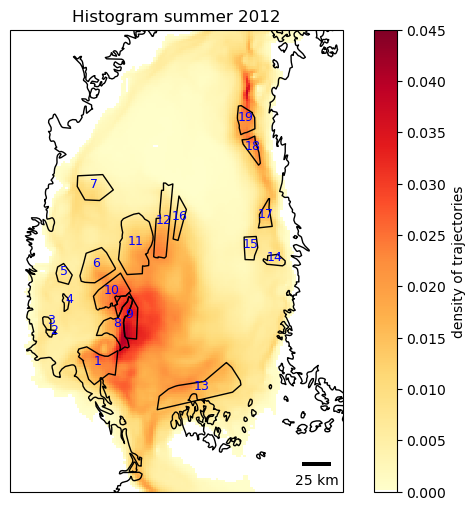

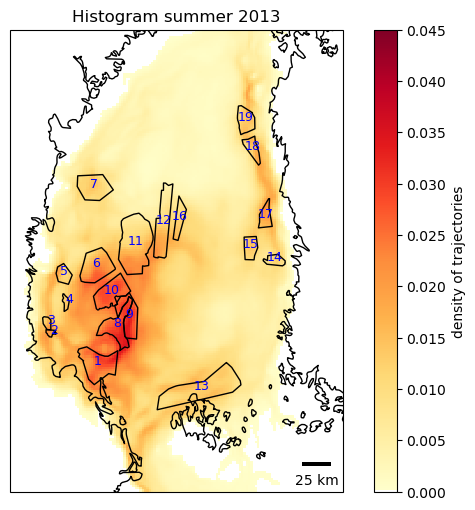

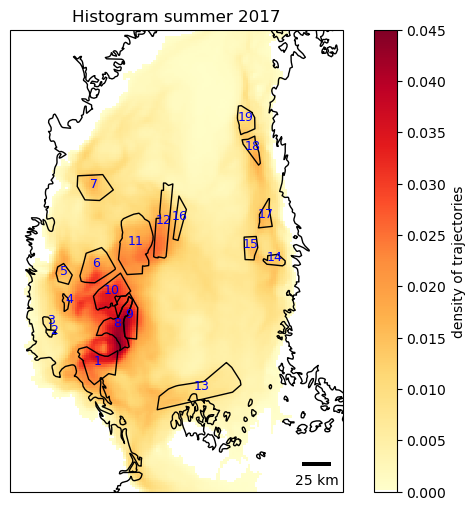

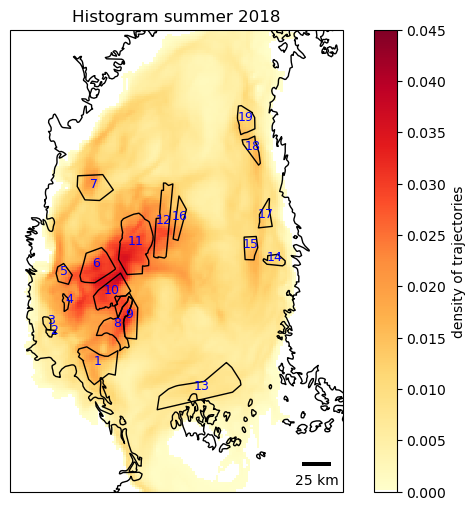

In [32]:
# # Plot one global map for each summer

# small = [2, 3, 4, 5, 9, 14, 15, 16, 17, 18, 19] # Smaller farms: one simulation for the whole summer
# medium = [1, 6, 7, 8, 10, 12] # Medium farms : summer divided in two simulations

# years = [2012, 2013, 2017, 2018]

# for year in years:
#     outfol = f'/projappl/project_2018610/scripts_jupyter_notebook/Density map/Plot_density_map/{year}/'
#     raster_nc1 = 'simulation_farm_{}_June_September_{}_{}_uniqsum_raster_metres.nc'.format(1, year, 6)
#     raster_nc2 = 'simulation_farm_{}_June_September_{}_{}_uniqsum_raster_metres.nc'.format(1, year, 7)
#     d1 = xr.open_dataset(infol+raster_nc1)
#     d2 = xr.open_dataset(infol+raster_nc2)
#     # average the data
#     da = nb_part[1]*(d1["N_count"]+d2["N_count"])/2     
    
#     for polygon in range(2, 20):
#         if polygon in small :           
#             raster_nc = 'simulation_farm_{}_June_September_{}_uniqsum_raster_metres.nc'.format(polygon, year)
#             d = xr.open_dataset(infol+raster_nc)        
#             da += nb_part[polygon]*d["N_count"]
            
#         elif polygon in medium :            
#             raster_nc1 = 'simulation_farm_{}_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 6)
#             raster_nc2 = 'simulation_farm_{}_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 7)
#             d1 = xr.open_dataset(infol+raster_nc1)
#             d2 = xr.open_dataset(infol+raster_nc2)
#             # average the data
#             da += nb_part[polygon]*(d1["N_count"]+d2["N_count"])/2
            
#         else :  # Large farms : summer divided in 2 + lower density of particles
#             raster_nc1 = 'simulation_farm_{}_6_part_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 6)
#             raster_nc2 = 'simulation_farm_{}_6_part_June_September_{}_{}_uniqsum_raster_metres.nc'.format(polygon, year, 7)
#             d1 = xr.open_dataset(infol+raster_nc1)
#             d2 = xr.open_dataset(infol+raster_nc2)
#             # average the data
#             da += nb_part[polygon]*(d1["N_count"]+d2["N_count"])/2
#     da = da/sum_part 
#     utm_proj = ccrs.UTM(zone=34)
    
#     fig, ax = plt.subplots(
#         figsize=(8, 6),
#         subplot_kw={"projection": utm_proj}
#     )
    
#     norm = mpl.colors.Normalize(vmin=0, vmax=0.045)

#     mesh = ax.pcolormesh(
#         da.x.values,
#         da.y.values,
#         da.values,
#         cmap=custom_cmap,
#         norm=norm,
#         transform=utm_proj,
#         shading='auto'
#     )
    
#     plt.colorbar(mesh, ax=ax, label='density of trajectories')
    
#     # Plot the wind farm as polygons
#     poly.plot(edgecolor="black", facecolor="none",ax=ax)
#     for _, row in poly.iterrows():
#         x, y = row.geometry.centroid.x, row.geometry.centroid.y
#         if row["FarmID"] in [2, 3, 4]:
#             ax.text(x, y, str(row["FarmID"]), color='blue', fontsize=9, ha='left')
#         else :
#             ax.text(x, y, str(row["FarmID"]), color='blue', fontsize=9, ha='center')

#     ax.coastlines()
#     scalebar = ScaleBar(1, location='lower right', units='m', length_fraction=0.1, rotation='horizontal-only')
#     ax.add_artist(scalebar)
#     ax.set_title(f"Histogram summer {year}")
#     plt.savefig(outfol+"density_map_{}.png".format(year))
        
#     plt.show()